In [22]:
# ======================================================================
# CELL-01 : IMPORT LIBRARIES
# ======================================================================

import numpy as np
import pandas as pd

import joblib

from sklearn.multioutput import MultiOutputRegressor

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (

    mean_squared_error,

    mean_absolute_error,

    r2_score

)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [23]:
# ======================================================================
# CELL-02 : LOAD TRAINING AND VALIDATION DATA
# ======================================================================

X_train = np.load(
    "X_train.npy"
)

Y_train = np.load(
    "Y_train.npy"
)

X_val = np.load(
    "X_val.npy"
)

Y_val = np.load(
    "Y_val.npy"
)

print("Training Data")

print(X_train.shape)

print(Y_train.shape)

print()

print("Validation Data")

print(X_val.shape)

print(Y_val.shape)


Training Data
(42951, 4)
(42951, 4)

Validation Data
(10738, 4)
(10738, 4)


In [24]:
# ======================================================================
# CELL-03 : LOAD OUTPUT SCALER
# ======================================================================

output_scaler = joblib.load(
    "output_scaler.pkl"
)

print("Scaler Loaded")

Scaler Loaded


In [25]:
# ======================================================================
# CELL-04 : LOAD ANN RESULTS
# ======================================================================

ann_results = pd.read_csv(
    "ANN_Validation_Predictions.csv"
)

ann_metrics_df = pd.read_csv(
    "ANN_Validation_Metrics.csv"
)

print(
    ann_results.shape
)

ann_metrics_df

(10738, 8)


,Output,RMSE,MAE,R2
0,Displacement,0.021630,0.015559,0.999926
1,Stress_L1,3.247404,2.115545,0.998686
2,Stress_L2,2.330956,1.473542,0.999293
3,Stress_L4,2.690917,1.561524,0.999219


In [26]:
# ======================================================================
# CELL-05 : DEFINE OUTPUTS
# ======================================================================

outputs = [

    "Displacement",

    "Stress_L1",

    "Stress_L2",

    "Stress_L4"

]

In [27]:
# ======================================================================
# CELL-06 : EVALUATION FUNCTION
# ======================================================================

def evaluate_model(
    actual,
    predicted
):

    rmse = np.sqrt(

        mean_squared_error(
            actual,
            predicted
        )

    )

    mae = mean_absolute_error(

        actual,
        predicted

    )

    r2 = r2_score(

        actual,
        predicted

    )

    relative_error = (

        np.abs(
            actual - predicted
        )

        /

        (
            np.max(
                np.abs(actual)
            )
            + 1e-8
        )

    ) * 100

    mean_relative_error = np.mean(
        relative_error
    )

    peak_error = (

        np.abs(

            np.max(actual)

            -

            np.max(predicted)

        )

        /

        (

            np.max(actual)

            + 1e-8

        )

    ) * 100

    return (

        rmse,

        mae,

        r2,

        mean_relative_error,

        peak_error

    )

In [28]:
# ======================================================================
# CELL-07 : PHYSICAL UNITS
# ======================================================================

Y_val_actual = (

    output_scaler.inverse_transform(
        Y_val
    )

)

print(
    Y_val_actual.shape
)

(10738, 4)


In [29]:
# ======================================================================
# CELL-08 : TRAIN XGBOOST
# ======================================================================

xgb_model = MultiOutputRegressor(

    XGBRegressor(

        n_estimators=500,

        max_depth=8,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        objective="reg:squarederror",

        random_state=42

    )

)

xgb_model.fit(

    X_train,

    Y_train

)

print("XGBoost Training Completed")

XGBoost Training Completed


In [30]:
# ======================================================================
# CELL-09 : SAVE XGBOOST
# ======================================================================

joblib.dump(

    xgb_model,

    "XGBoost_Model.pkl"

)

print("Model Saved")

Model Saved


In [31]:
# ======================================================================
# CELL-10 : VALIDATION PREDICTIONS
# ======================================================================

xgb_scaled = xgb_model.predict(
    X_val
)

xgb_predictions = (

    output_scaler.inverse_transform(
        xgb_scaled
    )

)

In [32]:
# ======================================================================
# CELL-11 : XGBOOST METRICS
# ======================================================================

xgb_metrics = []

for i, output in enumerate(outputs):

    rmse, mae, r2, mre, peak = (

        evaluate_model(

            Y_val_actual[:,i],

            xgb_predictions[:,i]

        )

    )

    xgb_metrics.append({

        "Output": output,

        "RMSE": rmse,

        "MAE": mae,

        "R2": r2,

        "MeanRelativeError": mre,

        "PeakError": peak

    })

xgb_metrics_df = pd.DataFrame(
    xgb_metrics
)

xgb_metrics_df

,Output,RMSE,MAE,R2,MeanRelativeError,PeakError
0,Displacement,0.104370,0.064957,0.998287,0.358878,2.383773
1,Stress_L1,13.780890,6.975468,0.976337,0.468152,22.579444
2,Stress_L2,11.250351,5.874994,0.983532,0.534090,14.607699
3,Stress_L4,15.546470,7.768707,0.973933,0.636779,14.291372


In [33]:
# ======================================================================
# CELL-12 : TRAIN RANDOM FOREST
# ======================================================================

rf_model = RandomForestRegressor(

    n_estimators=300,

    max_depth=25,

    random_state=42,

    n_jobs=-1

)

rf_model.fit(

    X_train,

    Y_train

)

print("RF Training Completed")

RF Training Completed


In [34]:
# ======================================================================
# CELL-13 : SAVE RF
# ======================================================================

joblib.dump(

    rf_model,

    "RandomForest_Model.pkl"

)

print("RF Saved")

RF Saved


In [35]:
# ======================================================================
# CELL-14 : RF PREDICTIONS
# ======================================================================

rf_scaled = rf_model.predict(
    X_val
)

rf_predictions = (

    output_scaler.inverse_transform(
        rf_scaled
    )

)

In [36]:
# ======================================================================
# CELL-15 : RF METRICS
# ======================================================================

rf_metrics = []

for i, output in enumerate(outputs):

    rmse, mae, r2, mre, peak = (

        evaluate_model(

            Y_val_actual[:,i],

            rf_predictions[:,i]

        )

    )

    rf_metrics.append({

        "Output": output,

        "RMSE": rmse,

        "MAE": mae,

        "R2": r2,

        "MeanRelativeError": mre,

        "PeakError": peak

    })

rf_metrics_df = pd.DataFrame(
    rf_metrics
)

rf_metrics_df

,Output,RMSE,MAE,R2,MeanRelativeError,PeakError
0,Displacement,0.117322,0.053107,0.997835,0.293406,4.596685
1,Stress_L1,8.556192,2.499431,0.990878,0.167747,21.549441
2,Stress_L2,7.786780,2.445546,0.992111,0.222322,11.013939
3,Stress_L4,11.248201,3.294693,0.986354,0.270057,21.516667


In [37]:
# ======================================================================
# CELL-16 : ANN METRICS
# ======================================================================

ann_metrics_df

,Output,RMSE,MAE,R2
0,Displacement,0.021630,0.015559,0.999926
1,Stress_L1,3.247404,2.115545,0.998686
2,Stress_L2,2.330956,1.473542,0.999293
3,Stress_L4,2.690917,1.561524,0.999219


In [38]:
# ======================================================================
# CELL-17 : MODEL COMPARISON
# ======================================================================

comparison_df = pd.DataFrame({

    "Model":[

        "ANN",

        "XGBoost",

        "Random Forest"

    ],

    "Average_R2":[

        ann_metrics_df["R2"].mean(),

        xgb_metrics_df["R2"].mean(),

        rf_metrics_df["R2"].mean()

    ]

})

comparison_df

,Model,Average_R2
0,ANN,0.999281
1,XGBoost,0.983022
2,Random Forest,0.991795


In [39]:
# ======================================================================
# CELL-18 : RANKING
# ======================================================================

ranking_df = comparison_df.sort_values(

    by="Average_R2",

    ascending=False

)

ranking_df.insert(

    0,

    "Rank",

    range(

        1,

        len(ranking_df)+1

    )

)

ranking_df

,Rank,Model,Average_R2
0,1,ANN,0.999281
2,2,Random Forest,0.991795
1,3,XGBoost,0.983022


In [40]:
# ======================================================================
# CELL-19 : SAVE RESULTS
# ======================================================================

xgb_metrics_df.to_csv(

    "XGBoost_Validation_Metrics.csv",

    index=False

)

rf_metrics_df.to_csv(

    "RandomForest_Validation_Metrics.csv",

    index=False

)

comparison_df.to_csv(

    "Validation_Model_Comparison.csv",

    index=False

)

ranking_df.to_csv(

    "Model_Ranking.csv",

    index=False

)

print("Results Saved")

Results Saved


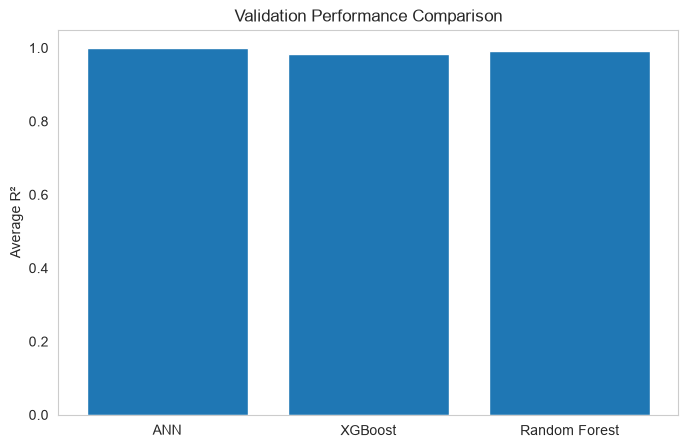

In [41]:
# ======================================================================
# CELL-20 : VISUALIZATION
# ======================================================================

import matplotlib.pyplot as plt

plt.figure(

    figsize=(8,5)

)

plt.bar(

    comparison_df["Model"],

    comparison_df["Average_R2"]

)

plt.ylabel(
    "Average R²"
)

plt.title(
    "Validation Performance Comparison"
)

plt.grid()

plt.show()

In [42]:
# ======================================================================
# CELL-21 : SUMMARY
# ======================================================================

print("="*70)

print("BENCHMARKING COMPLETED")

print("="*70)

print()

print("Generated Files")

print()

print("XGBoost_Model.pkl")

print("RandomForest_Model.pkl")

print()

print("ANN_Validation_Metrics.csv")

print("XGBoost_Validation_Metrics.csv")

print("RandomForest_Validation_Metrics.csv")

print()

print("Validation_Model_Comparison.csv")

print("Model_Ranking.csv")

print()

print()

print("="*70)

BENCHMARKING COMPLETED

Generated Files

XGBoost_Model.pkl
RandomForest_Model.pkl

ANN_Validation_Metrics.csv
XGBoost_Validation_Metrics.csv
RandomForest_Validation_Metrics.csv

Validation_Model_Comparison.csv
Model_Ranking.csv

Next Notebook
Notebook-05_Independent_Testing.ipynb

